In [1]:
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

In [2]:
RANDOM_STATE = 42
img_dir = Path("artifacts/figures")

In [3]:
df = pd.read_csv("S06-hw-dataset-04.csv")

In [4]:
print(f"Размер датасета: {df.shape}")
display(df.head())
print("\nInfo:")
df.info()

Размер датасета: (25000, 62)


,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
0,1,-1.250210,1.423474,-0.225004,-4.023138,-0.832729,-0.550874,1.772090,2.761690,-0.698750,...,10.938269,0.501178,1.600001,0.314212,1.209735,1.355697,-5.338924,1.153944,-0.153934,0
1,2,0.074328,0.376429,0.212831,-0.502074,2.017405,0.625496,1.943785,1.242030,-0.524090,...,7.775262,-4.550195,6.272586,-0.932162,-0.228543,1.735220,-3.827828,0.292165,0.273720,0
2,3,0.638481,0.060968,0.746760,2.479653,-0.292858,-0.078139,-2.918423,-0.013186,1.009135,...,-4.448447,-9.593179,-3.093519,0.029321,0.605511,0.829103,-0.085985,2.891408,0.766221,0
3,4,1.712916,-1.350969,-0.256473,1.622074,-0.445141,0.911932,-3.440345,1.505192,-1.104348,...,-1.619072,-3.237479,-5.474038,-1.582475,0.198137,3.823409,0.880395,1.148610,0.136732,0
4,5,0.905676,-0.206545,-0.068806,4.086026,-1.010045,-0.772644,-4.207688,2.506104,1.589143,...,-2.396844,-10.540129,-5.532811,-1.231203,0.000119,4.298572,-1.558235,0.924673,0.111668,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 62 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      25000 non-null  int64  
 1   f01     25000 non-null  float64
 2   f02     25000 non-null  float64
 3   f03     25000 non-null  float64
 4   f04     25000 non-null  float64
 5   f05     25000 non-null  float64
 6   f06     25000 non-null  float64
 7   f07     25000 non-null  float64
 8   f08     25000 non-null  float64
 9   f09     25000 non-null  float64
 10  f10     25000 non-null  float64
 11  f11     25000 non-null  float64
 12  f12     25000 non-null  float64
 13  f13     25000 non-null  float64
 14  f14     25000 non-null  float64
 15  f15     25000 non-null  float64
 16  f16     25000 non-null  float64
 17  f17     25000 non-null  float64
 18  f18     25000 non-null  float64
 19  f19     25000 non-null  float64
 20  f20     25000 non-null  float64
 21  f21     25000 non-null  floa

In [5]:
target_counts = df['target'].value_counts(normalize=True)
print("\nРаспределение классов (доли):")
print(target_counts)


Распределение классов (доли):
target
0    0.9508
1    0.0492
Name: proportion, dtype: float64


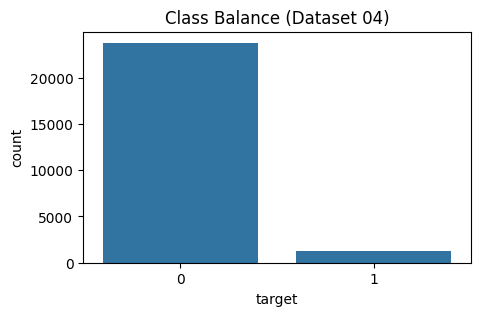

In [6]:
plt.figure(figsize=(5, 3))
sns.countplot(x='target', data=df)
plt.title("Class Balance (Dataset 04)")
plt.show()

In [7]:
X = df.drop(columns=['id', 'target'])
y = df['target']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Доля класса 1 в train: {y_train.mean():.4f}")
print(f"Доля класса 1 в test:  {y_test.mean():.4f}")

Train shape: (18750, 60), Test shape: (6250, 60)
Доля класса 1 в train: 0.0492
Доля класса 1 в test:  0.0491


baseline

In [9]:
results = []

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred = dummy.predict(X_test)
y_prob = dummy.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

results.append({
    "model": "Dummy",
    "accuracy": acc,
    "f1": f1,
    "roc_auc": roc
})


logreg_pipe = make_pipeline(
    StandardScaler(), 
    LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE)
)
logreg_pipe.fit(X_train, y_train)

y_pred = logreg_pipe.predict(X_test)
y_prob = logreg_pipe.predict_proba(X_test)[:, 1]

results.append({
    "model": "LogReg (Balanced)",
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
})

pd.DataFrame(results)

,model,accuracy,f1,roc_auc
0,Dummy,0.95088,0.000000,0.500000
1,LogReg (Balanced),0.77920,0.257266,0.841861


In [10]:
# Словарь для сохранения лучших моделей и их параметров
search_summaries = {}
best_estimators = {}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

dt_params = {
    'max_depth': [3, 5, 8, 12],
    'min_samples_leaf': [10, 20, 50],
    'class_weight': [None, 'balanced']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
dt_grid.fit(X_train, y_train)

best_estimators['DecisionTree'] = dt_grid.best_estimator_
search_summaries['DecisionTree'] = {
    'best_params': dt_grid.best_params_,
    'best_cv_score': dt_grid.best_score_
}

# Random Forest
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [5, 20],
    # 'max_features': ['sqrt', 0.5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    rf_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
rf_grid.fit(X_train, y_train)

best_estimators['RandomForest'] = rf_grid.best_estimator_
search_summaries['RandomForest'] = {
    'best_params': rf_grid.best_params_,
    'best_cv_score': rf_grid.best_score_
}

# Boosting (HistGradientBoosting)
gb_params = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [50, 100, 200],
    'max_depth': [3, 5, 10]
}

gb_grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
gb_grid.fit(X_train, y_train)

best_estimators['Boosting'] = gb_grid.best_estimator_
search_summaries['Boosting'] = {
    'best_params': gb_grid.best_params_,
    'best_cv_score': gb_grid.best_score_
}

print("Тренировка завершена")

Тренировка завершена


In [11]:
final_metrics = results.copy() # Копир результаты бейзлайнов

for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    final_metrics.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(final_metrics).sort_values(by="roc_auc", ascending=False)
display(results_df)

# победитель (по ROC-AUC)
best_model_name = results_df.iloc[0]['model']
best_model_obj = best_estimators.get(best_model_name, None) 

if best_model_obj is None: 

    if "LogReg" in best_model_name:
        best_model_obj = logreg_pipe
    else:
        best_model_obj = best_estimators['Boosting']

print(f"Победитель: {best_model_name}")

,model,accuracy,f1,roc_auc
4,Boosting,0.97840,0.723926,0.906786
3,RandomForest,0.97648,0.691824,0.906278
1,LogReg (Balanced),0.77920,0.257266,0.841861
2,DecisionTree,0.87712,0.366337,0.831763
0,Dummy,0.95088,0.000000,0.500000


Победитель: Boosting


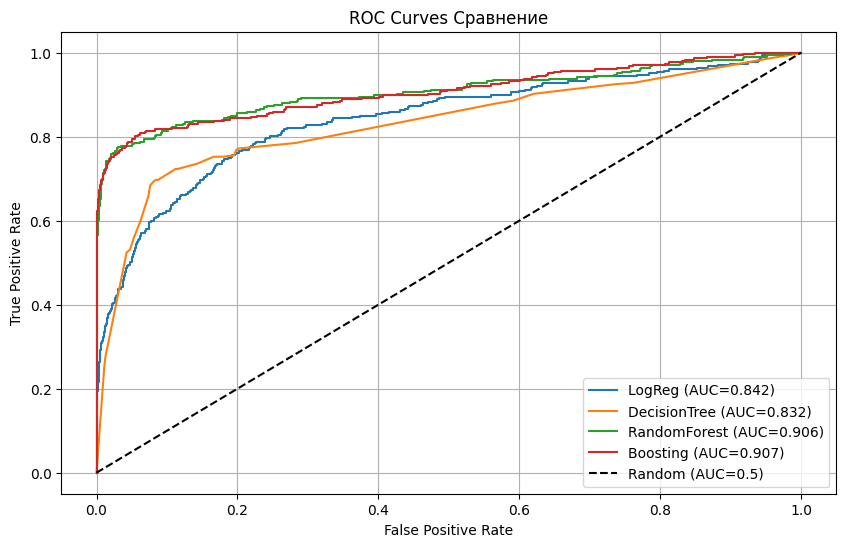

<Figure size 500x400 with 0 Axes>

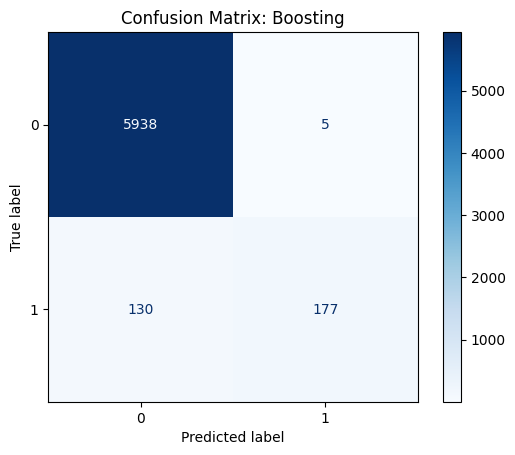

In [12]:
# ROC Curve для всех моделей
plt.figure(figsize=(10, 6))

# LogReg
fpr, tpr, _ = roc_curve(y_test, logreg_pipe.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, label=f"LogReg (AUC={roc_auc_score(y_test, logreg_pipe.predict_proba(X_test)[:, 1]):.3f})")

for name, model in best_estimators.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Сравнение")
plt.legend()
plt.grid(True)
plt.savefig("artifacts/figures/roc_curves.png")
plt.show()

plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(best_model_obj, X_test, y_test, cmap='Blues')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.savefig(f"artifacts/figures/conf_matrix_{best_model_name}.png")
plt.show()

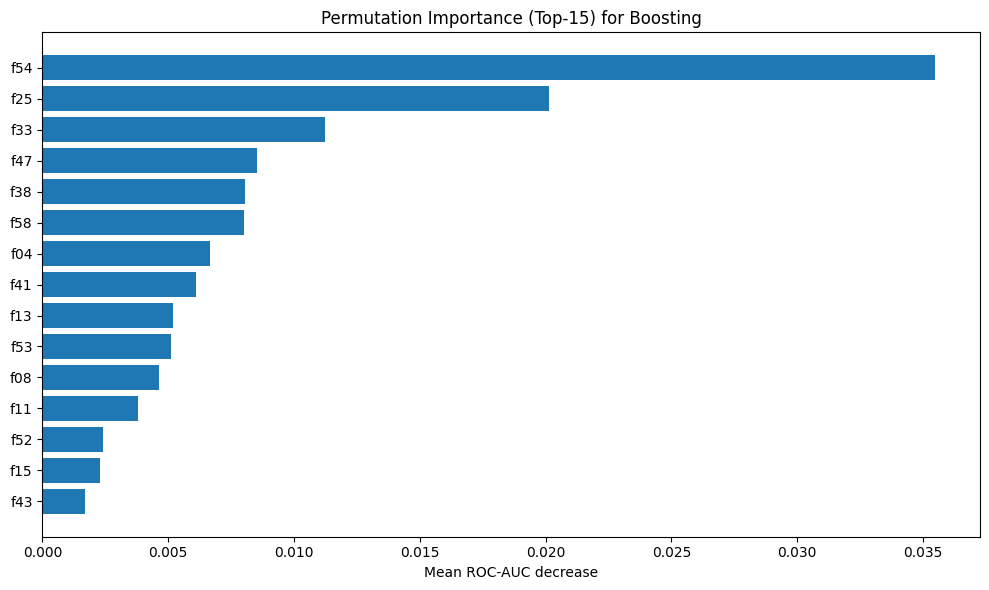

In [13]:

r = permutation_importance(best_model_obj, X_test, y_test,
                           n_repeats=10,
                           random_state=RANDOM_STATE,
                           scoring='roc_auc')

sorted_idx = r.importances_mean.argsort()[::-1][:15] # Топ-15

plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], r.importances_mean[sorted_idx])
plt.xlabel("Mean ROC-AUC decrease")
plt.title(f"Permutation Importance (Top-15) for {best_model_name}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("artifacts/figures/feature_importance.png")
plt.show()

In [15]:
# 1. метрики
results_df.to_json("artifacts/metrics_test.json", orient="records", indent=2)

# 2. параметры поиска
with open("artifacts/search_summaries.json", "w") as f:
    json.dump(search_summaries, f, indent=2)

# 3. лучшая модель
model_path = "artifacts/best_model.joblib"
joblib.dump(best_model_obj, model_path)

# 4. Метаданные
meta = {
    "best_model_label": best_model_name,
    "test_metrics": results_df.iloc[0].to_dict(),
    "random_state": RANDOM_STATE
}
with open("artifacts/best_model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Все артефакты сохранены в папку artifacts/")

Все артефакты сохранены в папку artifacts/


In [14]:
#  Проверка устойчивости 
print("Запуск проверки устойчивости...")
roc_scores = []
seeds = [1, 10, 42, 100, 999]

base_params = best_estimators['Boosting'].get_params()

for seed in seeds:
    current_params = base_params.copy()
    current_params['random_state'] = seed
    
    model = HistGradientBoostingClassifier(**current_params)
    
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    score = roc_auc_score(y_test, y_prob)
    roc_scores.append(score)
    print(f"Seed {seed}: ROC-AUC = {score:.4f}")

print(f"\nСреднее: {np.mean(roc_scores):.4f}, Std: {np.std(roc_scores):.4f}")

Запуск проверки устойчивости...
Seed 1: ROC-AUC = 0.8965
Seed 10: ROC-AUC = 0.9012
Seed 42: ROC-AUC = 0.9068
Seed 100: ROC-AUC = 0.9028
Seed 999: ROC-AUC = 0.9023

Среднее: 0.9019, Std: 0.0033
